# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [4]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [5]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

24
{'../outputs/2026-06-02/00:23:02_tbzhuDOP_dalu_81414/points.csv': 'tbzhuDOP_dalu', '../outputs/2026-06-02/01:49:15_tbzhuLinear_k2_81413/points.csv': 'tbzhuLinear_k2', '../outputs/2026-06-02/00:21:33_tbzhuLinear_dalu_81413/points.csv': 'tbzhuLinear_dalu', '../outputs/2026-06-02/01:51:19_tbzhuDOP_k2_81414/points.csv': 'tbzhuDOP_k2', '../outputs/2026-06-01/19:07:21_tbzhuLinear_c1355_81413/points.csv': 'tbzhuLinear_c1355', '../outputs/2026-06-01/16:24:34_zhuDOP_bc0_81398/points.csv': 'zhuDOP_bc0', '../outputs/2026-06-01/19:57:59_tbzhuLinear_bc0_81413/points.csv': 'tbzhuLinear_bc0', '../outputs/2026-06-01/16:01:14_zhuLinear_c1355_81399/points.csv': 'zhuLinear_c1355', '../outputs/2026-06-01/16:54:10_zhuDOP_apex1_81398/points.csv': 'zhuDOP_apex1', '../outputs/2026-06-01/17:30:19_zhuDOP_c5315_81398/points.csv': 'zhuDOP_c5315', '../outputs/2026-06-01/18:39:30_zhuDOP_k2_81398/points.csv': 'zhuDOP_k2', '../outputs/2026-06-01/18:39:38_zhuLinear_k2_81399/points.csv': 'zhuLinear_k2', '../outputs/

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. Hypervolume is the area dominated by the Pareto front and bounded by the original circuit reference point.

In [8]:
def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=(1.0, 1.0)):
    """2D minimization hypervolume relative to the original circuit point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [9]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
summary_df

,run_name,run_id,circuit,hypervolume,number of nondominated points
0,tbzhuDOP_c1355,0,C1355,0.081044,1
1,tbzhuDOP_c1355,1,C1355,0.081044,1
2,tbzhuDOP_c1355,2,C1355,0.071963,2
3,tbzhuDOP_c1355,3,C1355,0.072039,1
4,tbzhuDOP_c1355,4,C1355,0.080815,3
...,...,...,...,...,...
235,zhuLinear_k2,5,k2,0.180507,2
236,zhuLinear_k2,6,k2,0.180964,2
237,zhuLinear_k2,7,k2,0.192410,3
238,zhuLinear_k2,8,k2,0.167842,1


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [10]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,nondominated_stderr
0,tbzhuDOP_apex1,apex1,10,0.098350,0.005023,0.091790,0.103620,2.8,0.918937,2,4,0.001588,0.290593
1,tbzhuDOP_bc0,bc0,10,0.211114,0.007436,0.201978,0.220457,3.1,1.100505,1,4,0.002351,0.348010
2,tbzhuDOP_c1355,C1355,10,0.075557,0.006229,0.063034,0.081044,1.6,0.843274,1,3,0.001970,0.266667
3,tbzhuDOP_c5315,C5315,10,0.077858,0.006756,0.067088,0.090851,2.3,1.059350,1,4,0.002136,0.334996
4,tbzhuDOP_dalu,dalu,10,0.000000,0.000000,0.000000,0.000000,1.8,0.632456,1,3,0.000000,0.200000
5,tbzhuDOP_k2,k2,10,0.197093,0.003165,0.192736,0.201397,3.3,1.337494,2,5,0.001001,0.422953
6,tbzhuLinear_apex1,apex1,10,0.099503,0.004517,0.092404,0.102895,3.4,1.173788,2,5,0.001428,0.371184
7,tbzhuLinear_bc0,bc0,10,0.209045,0.008752,0.200904,0.220477,3.5,1.080123,2,6,0.002768,0.341565
8,tbzhuLinear_c1355,C1355,10,0.075595,0.004673,0.071886,0.081044,1.5,0.527046,1,2,0.001478,0.166667
9,tbzhuLinear_c5315,C5315,10,0.080464,0.006492,0.070502,0.093374,2.1,0.875595,1,4,0.002053,0.276887


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [11]:
# Choose the comparison target.
selected_circuit = points_df["circuit"].unique()[5]
# selected_circuit = 'bc0'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

circ_sum_df = summary_df.loc[
    summary_df["circuit"] == selected_circuit,
    ["run_name", "hypervolume", "number of nondominated points"]
].groupby("run_name").agg("mean")
circ_sum_df

Selected circuit: C5315
Selected experiments: ['tbzhuDOP_c5315', 'tbzhuLinear_c5315', 'zhuDOP_c5315', 'zhuLinear_c5315']


,hypervolume,number of nondominated points
run_name,,
tbzhuDOP_c5315,0.077858,2.3
tbzhuLinear_c5315,0.080464,2.1
zhuDOP_c5315,0.085232,2.9
zhuLinear_c5315,0.080908,2.6


In [12]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,tbzhuDOP_c5315,tbzhuLinear_c5315,C5315,100,0.020929,0.018288,0.001829,-0.007332,0.078947,0.296667,0.374040,0.037404,0.0,1.0
1,tbzhuDOP_c5315,zhuDOP_c5315,C5315,100,0.032029,0.022897,0.002290,-0.002820,0.078947,0.224333,0.348420,0.034842,0.0,1.0
2,tbzhuDOP_c5315,zhuLinear_c5315,C5315,100,0.022452,0.018655,0.001865,-0.003948,0.078947,0.351667,0.345121,0.034512,0.0,1.0
3,tbzhuLinear_c5315,tbzhuDOP_c5315,C5315,100,0.011995,0.016594,0.001659,-0.019177,0.078947,0.484167,0.408876,0.040888,0.0,1.0
4,tbzhuLinear_c5315,zhuDOP_c5315,C5315,100,0.024508,0.021488,0.002149,-0.012972,0.078947,0.294000,0.343613,0.034361,0.0,1.0
5,tbzhuLinear_c5315,zhuLinear_c5315,C5315,100,0.015955,0.017146,0.001715,-0.007896,0.078947,0.419167,0.369582,0.036958,0.0,1.0
6,zhuDOP_c5315,tbzhuDOP_c5315,C5315,100,0.005833,0.011561,0.001156,-0.008460,0.052632,0.585833,0.392013,0.039201,0.0,1.0
7,zhuDOP_c5315,tbzhuLinear_c5315,C5315,100,0.007807,0.011827,0.001183,-0.006768,0.052632,0.529167,0.422686,0.042269,0.0,1.0
8,zhuDOP_c5315,zhuLinear_c5315,C5315,100,0.006542,0.012320,0.001232,-0.006768,0.052632,0.638333,0.383373,0.038337,0.0,1.0
9,zhuLinear_c5315,tbzhuDOP_c5315,C5315,100,0.011050,0.013378,0.001338,-0.010152,0.052632,0.435833,0.384031,0.038403,0.0,1.0


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [13]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print(selected_front_df.to_string(index=False))
selected_front_df

Pareto fronts for circuit: C5315
Experiments: ['tbzhuDOP_c5315', 'tbzhuLinear_c5315', 'zhuDOP_c5315', 'zhuLinear_c5315']
         run_name circuit  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
   tbzhuDOP_c5315   C5315         0.725888          0.842105        0.274112         0.157895  1287     32
   tbzhuDOP_c5315   C5315         0.726452          0.815789        0.273548         0.184211  1288     31
   tbzhuDOP_c5315   C5315         0.728144          0.710526        0.271856         0.289474  1291     27
   tbzhuDOP_c5315   C5315         0.736041          0.684211        0.263959         0.315789  1305     26
   tbzhuDOP_c5315   C5315         0.750141          0.657895        0.249859         0.342105  1330     25
tbzhuLinear_c5315   C5315         0.722504          0.736842        0.277496         0.263158  1281     28
tbzhuLinear_c5315   C5315         0.725888          0.710526        0.274112         0.289474  1287     27
tbzhuLinear_c5315   C53

,run_name,circuit,normalized_size,normalized_depth,size_reduction,depth_reduction,size,depth
0,tbzhuDOP_c5315,C5315,0.725888,0.842105,0.274112,0.157895,1287,32
1,tbzhuDOP_c5315,C5315,0.726452,0.815789,0.273548,0.184211,1288,31
2,tbzhuDOP_c5315,C5315,0.728144,0.710526,0.271856,0.289474,1291,27
3,tbzhuDOP_c5315,C5315,0.736041,0.684211,0.263959,0.315789,1305,26
4,tbzhuDOP_c5315,C5315,0.750141,0.657895,0.249859,0.342105,1330,25
5,tbzhuLinear_c5315,C5315,0.722504,0.736842,0.277496,0.263158,1281,28
6,tbzhuLinear_c5315,C5315,0.725888,0.710526,0.274112,0.289474,1287,27
7,tbzhuLinear_c5315,C5315,0.740553,0.684211,0.259447,0.315789,1313,26
8,tbzhuLinear_c5315,C5315,0.742245,0.657895,0.257755,0.342105,1316,25
9,zhuDOP_c5315,C5315,0.726452,0.736842,0.273548,0.263158,1288,28


## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

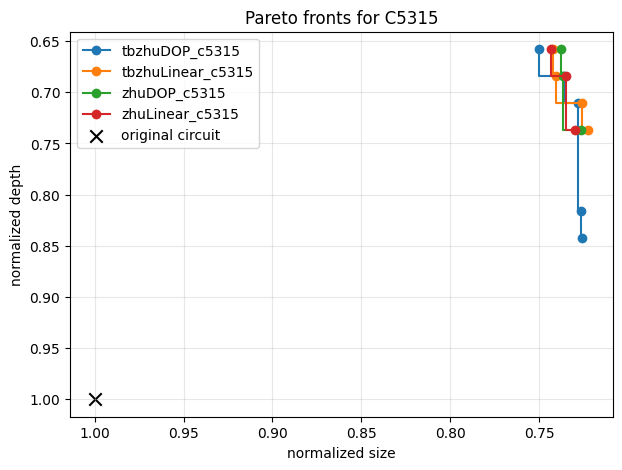

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()